<a href="https://colab.research.google.com/github/grullaandrea-png/mushroom_classification_model_dervishi/blob/main/Mushrooms_alexnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!mkdir -p /content/dataset
!unzip "/content/drive/MyDrive/Deep_learning_project/archive (9).zip" -d "/content/dataset"

Output streaming troncato alle ultime 5000 righe.
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AE2014PIC62591207.jpg_545e1a0f-1d78-492a-8709-9f5ceb43569f.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AE2014PIC62591207.jpg_e4d7c54d-d437-43fe-b6b5-eab0ddbd559a.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AE2015PIC76548267.jpg_61ebf998-b459-4fc7-8d59-d17a49089c7f.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_ALO2015PIC74715276.jpg_dbd2bff2-da30-47c6-ae31-5cdc47175911.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_ALO2015PIC74715276.jpg_ff6e1280-44e5-44aa-8220-435738b08997.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_ANB2016-9178693_rkxA21PQyx.jpg_89b988b0-c4ae-4c8c-8c92-879b4e0d2a90.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AS2009PIC41853880.jpg_27349cea-c52c-483d-b2dd-e99ced31da85.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AS20

In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# 1. Definisci le trasformazioni (as ResNet18)
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

path = '/content/dataset/Data'
full_dataset = datasets.ImageFolder(root=path)


# 3. Dividi in 70% Train, 20% Test, 10% Validation
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
test_size = int(0.20 * total_size)
val_size = total_size - train_size - test_size

train_raw, test_raw, val_raw = random_split(full_dataset, [train_size, test_size, val_size])

# 4. Classe per applicare la trasformazione giusta al gruppo giusto
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# 5. Applica le trasformazioni: nota come ora peschiamo la chiave 'train' o 'val' dal dizionario
train_dataset = ApplyTransform(train_raw, transform=data_transforms['train'])
val_dataset = ApplyTransform(val_raw, transform=data_transforms['val'])
test_dataset = ApplyTransform(test_raw, transform=data_transforms['val'])

# 6. Crea i DataLoader finali
batch_size = 32

# Usa 2 o 4 worker (processi paralleli) per leggere le foto, e pin_memory per trasferirle velocemente alla GPU
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Immagini per Training: {len(train_dataset)}")
print(f"Immagini per Validation: {len(val_dataset)}")
print(f"Immagini per Test: {len(test_dataset)}")

Immagini per Training: 8400
Immagini per Validation: 1200
Immagini per Test: 2400


In [10]:
import torch
from torch import nn

# AlexNet con Batch Normalization
net = nn.Sequential(
    # 1. Primo blocco
    nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=1),
    nn.BatchNorm2d(96), # AGGIUNTO (il numero deve essere uguale a quello di output della Conv2d)
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    # 2. Secondo blocco
    nn.Conv2d(96, 256, kernel_size=5, padding=2),
    nn.BatchNorm2d(256), # AGGIUNTO
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    # 3. Terzo, Quarto e Quinto blocco
    nn.Conv2d(256, 384, kernel_size=3, padding=1),
    nn.BatchNorm2d(384), # AGGIUNTO
    nn.ReLU(),

    nn.Conv2d(384, 384, kernel_size=3, padding=1),
    nn.BatchNorm2d(384), # AGGIUNTO
    nn.ReLU(),

    nn.Conv2d(384, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256), # AGGIUNTO
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),

    # 5. Strati Densi (qui si usa BatchNorm1d perché i dati sono piatti)
    nn.Linear(6400, 4096),
    nn.BatchNorm1d(4096), # AGGIUNTO
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(4096, 4096),
    nn.BatchNorm1d(4096), # AGGIUNTO
    nn.ReLU(),
    nn.Dropout(p=0.5),

    # 6. Output finale
    nn.Linear(4096, 12)
)

In [2]:
# Installa la libreria (necessario solo la prima volta o se riavvii l'ambiente)
!pip install d2l==1.0.a1.post0
from d2l import torch as d2l  # Qui definiamo il nome 'd2l'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.6 MB/s eta 0:00:00


In [9]:
import torch
from d2l import torch as d2l

def evaluate_accuracy_gpu(net, data_iter, device=None):
    """Calcola l'accuratezza del modello su un dataset usando la GPU."""
    if isinstance(net, torch.nn.Module):
        net.eval()  # Mette la rete in modalità valutazione (disattiva il Dropout)
        if not device:
            device = next(iter(net.parameters())).device

    metric = d2l.Accumulator(2)

    with torch.no_grad(): # Disattiva il calcolo dei gradienti per risparmiare memoria
        for X, y in data_iter:
            if isinstance(X, list):
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())

    return metric[0] / metric[1]

print("Funzione 'evaluate_accuracy_gpu' caricata correttamente!")

def train_mushrooms(net, train_loader, val_loader, num_epochs, lr, device=d2l.try_gpu()):
    # 1. Inizializzazione pesi (Xavier)
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)

    net.apply(init_weights)
    print('Training su:', device)
    net.to(device)

    # 2. Ottimizzatore AdamW + Scheduler
    optimizer = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'val acc'])

    timer, num_batches = d2l.Timer(), len(train_loader)

    for epoch in range(num_epochs):
        metric = d2l.Accumulator(3)
        net.train()

        for i, (X, y) in enumerate(train_loader):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)

            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()

            # --- IL PARACADUTE: GRADIENT CLIPPING ---
            # Impedisce ai gradienti di esplodere, evitando che la loss diventi altissima
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)

            optimizer.step()

            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()

            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]

            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches, (train_l, train_acc, None))

        val_acc = evaluate_accuracy_gpu(net, val_loader)
        animator.add(epoch + 1, (None, None, val_acc))

        # --- POSIZIONE CORRETTA DELLO SCHEDULER ---
        # Si aggiorna DOPO che l'epoca è finita
        scheduler.step(val_acc)

        # Stampa il Learning Rate attuale per monitorare lo scheduler
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoca {epoch+1}: Loss {train_l:.3f}, Train Acc {train_acc:.3f}, Val Acc {val_acc:.3f}, LR {current_lr:.6f}')

Funzione 'evaluate_accuracy_gpu' caricata correttamente!


Epoca 30: Loss 1.256, Train Acc 0.585, Val Acc 0.586, LR 0.000100


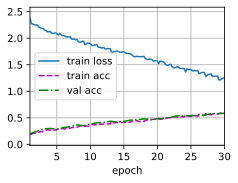

In [10]:
# 1. Definiamo i parametri (Learning Rate e Numero di Epoche)
lr, num_epochs = 0.0001, 30

# 2. Lanciamo la funzione di addestramento
# net: la tua AlexNet a 12 classi
# train_loader: i dati per imparare (70%)
# val_loader: i dati per controllare (10%) - Usiamo val_loader qui, non test_loader!
train_mushrooms(net, train_loader, val_loader, num_epochs, lr, device=d2l.try_gpu())

In [ ]:
save_path = '/content/drive/MyDrive/Deep_learning_project/mushroom_alexnet_model.pth'

In [8]:
import torch
from torch import nn

# define alexNet
net = nn.Sequential(
    nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),     # 1. Primo strato convoluzionale: cerca forme semplici (bordi, colori)
    nn.MaxPool2d(kernel_size=3, stride=2), # Riduce la dimensione per focalizzarsi sulle info importanti
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(), # 2. Secondo strato: cerca pattern più complessi (cerchi, trame)
    nn.MaxPool2d(kernel_size=3, stride=2),

    # 3. Terzo, Quarto e Quinto strato: estraggono dettagli molto specifici
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(), # 4. Trasformazione: passiamo da una griglia di pixel a una lista piatta di numeri
    nn.Linear(6400, 4096), nn.ReLU(), # 5. Strati densi (Cervello): prendono le caratteristiche e decidono la classe
    nn.Dropout(p=0.5), # Evita che la rete impari a memoria le foto (Overfitting)
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),

    # 6. Output finale: 12 neuroni, uno per ogni tipo di fungo
    nn.Linear(4096, 12)
)